#Import Libraries


In [1]:
import pandas as pd
import numpy as np

In [2]:
import re
import nltk
import spacy

In [3]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

#Download stopwords

In [ ]:
nltk.download_shell()

NLTK Downloader
---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> d

Download which package (l=list; x=cancel)?
  Identifier> stopwords


      Unzipping corpora/stopwords.zip.



---------------------------------------------------------------------------
    d) Download   l) List    u) Update   c) Config   h) Help   q) Quit
---------------------------------------------------------------------------
Downloader> q


In [4]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
df = pd.read_csv('/content/SMSSpamCollection',sep='\t',header=None,names=['label','message'])

In [6]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [8]:
df.shape

(5572, 2)

In [9]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [10]:
df.isnull().sum()

,0
label,0
message,0


In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [13]:
df.groupby('label').describe()

message                                                               
        count unique                                                top freq
label                                                                       
ham      4825   4516                             Sorry, I'll call later   30
spam      747    653  Please call our customer service representativ...    4

In [14]:
df['length'] = df['message'].apply(len)

In [15]:
df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='Frequency'>

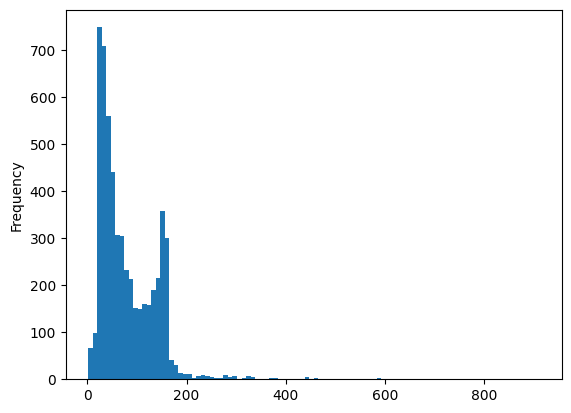

In [17]:
df['length'].plot.hist(bins=100)

In [18]:
df['length'].describe()

,length
count,5572.000000
mean,80.489950
std,59.942907
min,2.000000
25%,36.000000
50%,62.000000
75%,122.000000
max,910.000000


array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

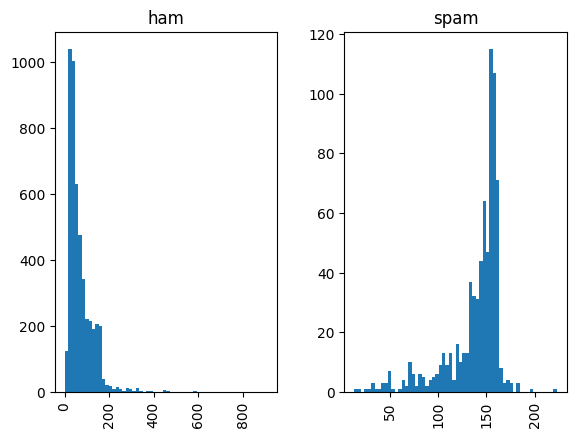

In [19]:
df.hist(column='length',by='label',bins=60)

# Preprocessing : Step 1 - Remove special characters

In [20]:
df['message'].head()

,message
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...
3,U dun say so early hor... U c already then say...
4,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
#df['message'] = re.sub(r"^a-z\s","",df['message'])

In [22]:
df_original = df.copy()

# Preprocessing : Step 1 - Covert to lowercase

In [23]:
# Convert to lower case first

df['message'] = df['message'].str.lower()

# Preprocessing : Step 2 - Remove special characters

In [24]:
# Remove any special characters (basically everything other than lower case characters (a to z) and space (\s) )

df['message'] = df['message'].str.replace(r"[^a-z\s]","",regex=True)

In [25]:
df['message'].head()

,message
0,go until jurong point crazy available only in ...
1,ok lar joking wif u oni
2,free entry in a wkly comp to win fa cup final...
3,u dun say so early hor u c already then say
4,nah i dont think he goes to usf he lives aroun...


# Preprocessing : Step 3 - Remove stop words

In [26]:
stop_words=set(stopwords.words('english'))
print(stop_words)

{'ain', "we'd", "you'd", "i've", 'on', 'hasn', "hasn't", 'didn', 'isn', 'y', 'just', "they'd", 'whom', 'doesn', 'who', 'themselves', 'over', 'aren', 'his', 'against', 'needn', 'were', "needn't", 'while', 'between', 'under', 'then', 'wasn', "we've", 'few', 'yourselves', "wasn't", 'her', 'ma', 'through', 'he', "he's", 'more', 'with', 'won', 'out', "you've", 'hers', 'is', 'such', 'only', 'will', 'no', 'here', 'weren', 'i', 'itself', 'into', "haven't", 'too', 'himself', 'any', 'if', 'ourselves', "she's", 'don', 'own', "mustn't", 'some', 'but', 'did', 'to', 's', 'has', 'very', "you're", 'above', 'can', 'wouldn', 'mustn', "they're", 'at', 'other', 'your', "couldn't", 'should', 'until', 'so', 'up', 'yours', 'by', 'was', "they've", 'm', 'off', 'being', "shouldn't", "won't", "doesn't", 'once', "aren't", 'have', "isn't", 'after', 'herself', 'having', 'our', 'shouldn', 'not', "don't", 'o', 'in', 'it', "it'll", "i'll", 'been', 'same', 'of', 'about', 'we', 'below', 'am', 'further', 'ours', 'which',

In [ ]:
#df['message'] = "".join(df['message'])

In [27]:
df['message'][0]

'go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat'

In [28]:
#.apply(lambda x: " ".join(word for word in input.split() if word not in stop_words))

print(df['message'][0].split())

['go', 'until', 'jurong', 'point', 'crazy', 'available', 'only', 'in', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'there', 'got', 'amore', 'wat']


In [29]:
print(" ".join(word for word in df['message'][0].split() if word not in stop_words))

go jurong point crazy available bugis n great world la e buffet cine got amore wat


In [30]:
print(" ".join(word for word in df['message'][0].split() if word not in stop_words))

go jurong point crazy available bugis n great world la e buffet cine got amore wat


In [31]:
df['processed_message'] = df['message'].apply(
    lambda x:  " ".join(word for word in x.split() if word not in stop_words)
    )

In [32]:
df.head()

,label,message,length,processed_message
0,ham,go until jurong point crazy available only in ...,111,go jurong point crazy available bugis n great ...
1,ham,ok lar joking wif u oni,29,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final...,155,free entry wkly comp win fa cup final tkts st ...
3,ham,u dun say so early hor u c already then say,49,u dun say early hor u c already say
4,ham,nah i dont think he goes to usf he lives aroun...,61,nah dont think goes usf lives around though


In [35]:
from sklearn.preprocessing import LabelEncoder

In [36]:
encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [39]:
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['processed_message'])

y = df['label']

In [41]:
print(X.shape)

(5572, 3000)


In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(4457, 3000)
(1115, 3000)


In [43]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [44]:
y_pred = model.predict(X_test)

In [45]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9721973094170404

Classification Report

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.80      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115


Confusion Matrix

[[965   1]
 [ 30 119]]


In [57]:
def predict_spam(message):

    message = message.lower()

    message = re.sub(r"[^a-z\s]","",message)

    stop_words=set(stopwords.words('english'))

    cleaned = " ".join(word for word in message.split() if word not in stop_words)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)[0]

    if prediction == 1:
        return "SPAM"
    else:
        return "HAM"

In [60]:
msg1 = df['message'][0]

msg2 = df['message'][2]

msg3 = "Congratulations! You won a free iPhone. Click now."

print(msg1)
print("Prediction :", predict_spam(msg1))

print("\n")

print(msg2)
print("Prediction :", predict_spam(msg2))

print("\n")

print(msg3)
print("Prediction :", predict_spam(msg3))



go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
Prediction : HAM


free entry in  a wkly comp to win fa cup final tkts st may  text fa to  to receive entry questionstd txt ratetcs apply overs
Prediction : SPAM


Congratulations! You won a free iPhone. Click now.
Prediction : SPAM


In [59]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))

Accuracy : 0.9632286995515695


In [ ]:

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

corpus = [
    "I love machine learning",
    "I love NLP",
    "NLP is amazing"
]

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(corpus)

print(tfidf.get_feature_names_out())
print(pd.DataFrame(X.toarray()))

['amazing' 'is' 'learning' 'love' 'machine' 'nlp']
          0         1         2         3         4         5
0  0.000000  0.000000  0.622766  0.473630  0.622766  0.000000
1  0.000000  0.000000  0.000000  0.707107  0.000000  0.707107
2  0.622766  0.622766  0.000000  0.000000  0.000000  0.473630
